# 02. PyTorch Neural Network Classification

This notebook builds a binary classification model in PyTorch, starting with a synthetic dataset and ending with a simple train/test loop.

**Resources**
1. Notebook: https://www.learnpytorch.io/02_pytorch_classification/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s


## Setup & Environment Check

Import the core libraries and detect the available device up front so every tensor and model can be moved to the right place later in the notebook.


In [107]:
# Capture runtime details so later cells can choose the right device.
import platform
import torch
from torch import nn
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt

# Keep notebook output focused on the example results.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Training and inference will use the CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


In [108]:
# Generate a simple binary classification dataset with two concentric circles.
import sklearn
from sklearn import datasets

n_samples = 1000
X, y = datasets.make_circles(n_samples=n_samples, noise=0.03, random_state=42)

len(X), len(y)

(1000, 1000)

In [109]:
print(f"The first 6 X values: {X[:6]}")
print(f"The first 6 y values: {y[:6]}")

The first 6 X values: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]
 [-0.47964637  0.67643477]]
The first 6 y values: [1 1 1 1 0 1]


In [110]:
import pandas as pd
# Put the features and labels in a DataFrame so the dataset is easy to inspect and plot.
circles_df = pd.DataFrame(X, columns=["X1", "X2"])
circles_df["Label"] = y

In [111]:
circles_df.head(10)

,X1,X2,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


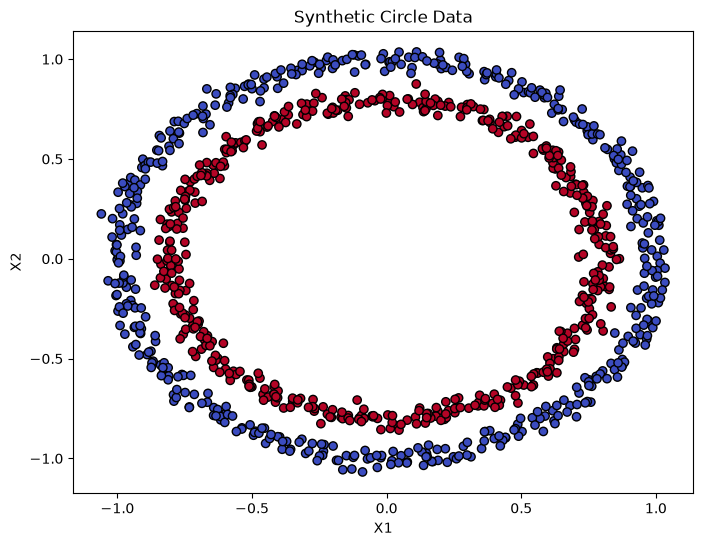

In [112]:
plt.figure(figsize=(8, 6))
# Visualize the class layout; the concentric circles make this a non-linear problem.
plt.scatter(circles_df["X1"], circles_df["X2"], c=circles_df["Label"], cmap="coolwarm", edgecolor="k")
plt.title("Synthetic Circle Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

# This toy dataset is only for experimentation and practice.

In [113]:
# Convert the NumPy arrays to float32 tensors so PyTorch can work with them efficiently.
from sklearn.model_selection import train_test_split

X = torch.as_tensor(X, dtype=torch.float32)
y = torch.as_tensor(y, dtype=torch.float32)

type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # Hold out 20% of the data for evaluation.
    random_state=42,
 )

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## Building the Model

We’ll define a small feed-forward network, choose a binary classification loss, and wrap training and evaluation in a loop so each step stays easy to inspect.

**Resources**
1. NN_Playground: https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.43617&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false

In [115]:
# Define a minimal feed-forward network with one hidden layer.
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=5)  # Map the two inputs into a small hidden representation.
        self.layer2 = nn.Linear(in_features=5, out_features=1)  # Produce one logit for binary classification.

    def forward(self, x):
        # Return raw logits; BCEWithLogitsLoss will handle the sigmoid step internally.
        return self.layer2(self.layer1(x))
    
# Create an instance of the model and inspect its initial parameters.
model_0 = CircleModelV0().to(DEVICE)
print(model_0)
model_0.state_dict()  # Inspect the randomly initialized weights and biases.

CircleModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)


OrderedDict([('layer1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='cuda:0')),
             ('layer1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='cuda:0')),
             ('layer2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='cuda:0')),
             ('layer2.bias', tensor([-0.2060], device='cuda:0'))])

In [116]:
# A Sequential model is shorter to write, but it is only a good fit for simple layer stacks.
model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),  # Map the inputs into a hidden layer.
    nn.Linear(in_features=5, out_features=1)  # Emit one binary-classification logit.
).to(DEVICE)

print(model_1)
model_1.state_dict()  # Inspect the randomly initialized weights and biases.

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)


OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [117]:
# Check the model's initial predictions before any training to establish a baseline.
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(DEVICE))
print(f"Untrained predictions length: {len(untrained_preds)},\nShape: {untrained_preds.shape}\n")
print(f"Untrained predictions first 5: {untrained_preds[:5]}")

Untrained predictions length: 200,
Shape: torch.Size([200, 1])

Untrained predictions first 5: tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='cuda:0')


In [118]:
# BCEWithLogitsLoss combines sigmoid and binary cross-entropy, so it expects raw logits.
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

# Return classification accuracy as a percentage.
def accuracy_fn(y_true, y_pred):
    """Return classification accuracy as a percentage."""
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [119]:
# Switch to evaluation mode before generating example predictions.
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(DEVICE))[:5]  # Grab the first few logits for a quick sanity check.
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='cuda:0')

In [120]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [121]:
# use sigmoid activation to convert logits to probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4683],
        [0.4758],
        [0.4524],
        [0.4728],
        [0.4584]], device='cuda:0')

In [122]:
y_preds = torch.round(y_pred_probs) # Round the probabilities to get predicted labels (0 or 1)

# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(DEVICE))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze())) # Check if the two methods of getting predicted labels are the same

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [124]:
# Set seeds so this example is repeatable on supported devices.
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 100

# Move the training and test tensors to the selected device once, outside the loop.
X_train, y_train = X_train.to(DEVICE), y_train.to(DEVICE)
X_test, y_test = X_test.to(DEVICE), y_test.to(DEVICE)

for epoch in range(EPOCHS):
    model_0.train()  # Enable training behavior such as gradient tracking.

    # Forward pass: produce raw logits, then convert them to labels for metrics.
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Compute loss on logits and accuracy on predicted class labels.
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # Backward pass: clear old gradients, backpropagate, and update parameters.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()  # Disable training-specific behavior before evaluating on the test set.
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:  # Log progress regularly without overwhelming the output.
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f} | Accuracy: {acc:.2f}%")
        print(f"Test Loss: {test_loss.item():.4f} | Test Accuracy: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.6940 | Accuracy: 50.00%
Test Loss: 0.6962 | Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.6940 | Accuracy: 49.88%
Test Loss: 0.6962 | Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.6939 | Accuracy: 48.75%
Test Loss: 0.6961 | Test Accuracy: 47.50%
Epoch: 30 | Loss: 0.6938 | Accuracy: 44.88%
Test Loss: 0.6961 | Test Accuracy: 42.50%
Epoch: 40 | Loss: 0.6937 | Accuracy: 42.50%
Test Loss: 0.6960 | Test Accuracy: 41.50%
Epoch: 50 | Loss: 0.6937 | Accuracy: 41.12%
Test Loss: 0.6960 | Test Accuracy: 40.50%
Epoch: 60 | Loss: 0.6936 | Accuracy: 42.25%
Test Loss: 0.6960 | Test Accuracy: 43.50%
Epoch: 70 | Loss: 0.6936 | Accuracy: 43.25%
Test Loss: 0.6959 | Test Accuracy: 45.00%
Epoch: 80 | Loss: 0.6935 | Accuracy: 44.75%
Test Loss: 0.6959 | Test Accuracy: 46.00%
Epoch: 90 | Loss: 0.6935 | Accuracy: 45.62%
Test Loss: 0.6959 | Test Accuracy: 46.50%
Epoch: 99 | Loss: 0.6934 | Accuracy: 45.88%
Test Loss: 0.6959 | Test Accuracy: 47.00%


## Video Timestamp

This section ends after turning the raw dataset into tensors, around 09:09:41. The next part covers the train/test split, model definition, and training loop.
